<a href="https://colab.research.google.com/github/801-Hillside-Terrace/SMART-2026/blob/main/week4/Week4_NeuralNetworksContinued.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Topics: Neural Networks


We will look at a regression case now rather than the classification case from the assignment.

In [7]:
#imports
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import csv

# set seed
torch.manual_seed(801)

Let's make the true model $y=x^2+\epsilon$, but our input feature will be $x$ instead of $x^2$ so linear regression would just fit a straight line here and fail to capture the parabolic relationship.  

We will fit a neural network with a single hidden layer containing 2 nodes/neurons and use the hyperbolic tangent activation function.

In [8]:
x = torch.linspace(-2, 2, 100).view(-1,1) # 100 points between -2 and 2 for x
y = x**2 + torch.randn_like(x) * 0.1 # y = x^2 + noise relationship

# simple neural network
model = nn.Sequential(
    nn.Linear(1, 2), # single input x, 2 node hidden layer
    nn.Tanh(), # hyperbolic tangent activation comment this out for Question 6
    #nn.ReLU(), # use this instead for Question 6
    nn.Linear(2, 1) # single node output layer (predicting just y)
)

criterion = nn.MSELoss() # MSE loss function since we are doing regression
optimizer = optim.SGD(model.parameters(), lr=0.05)

for epoch in range(5000):
    optimizer.zero_grad()

    # forward pass
    preds = model(x)
    # compute loss
    loss = criterion(preds, y)

    # backward pass
    loss.backward()
    optimizer.step()

# get predicted values:
with torch.no_grad():
    y_pred = model(x)

Here's the plot of the raw data.  Clearly, linear regression with just $x$ as the input would heavily underfit here.

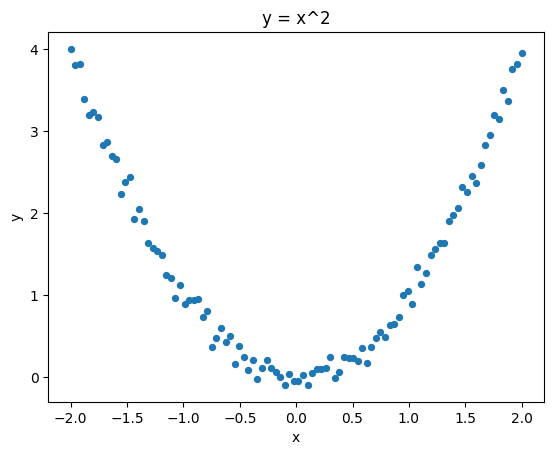

In [9]:
plt.scatter(x.numpy(), y.numpy(), s=18)
plt.title('y = x^2')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Let's look at the outputs of the hidden layer.  Remember our input feature is just $x$.  See that the hidden layer transforms $x$ into two pieces that have a non-linear relationship with $x$.  These pieces can then be multiplied by the final set of weights with the added bias for the output layer to approximate $x^2$ and give the near optimal fit.  Essentially we split $x$ into two non-linear parts and those parts can be scaled and summed in a way that approximates $x^2$ instead of being stuck with just $x$.  The neural network has sort of created $x^2$ as a feature on its own.

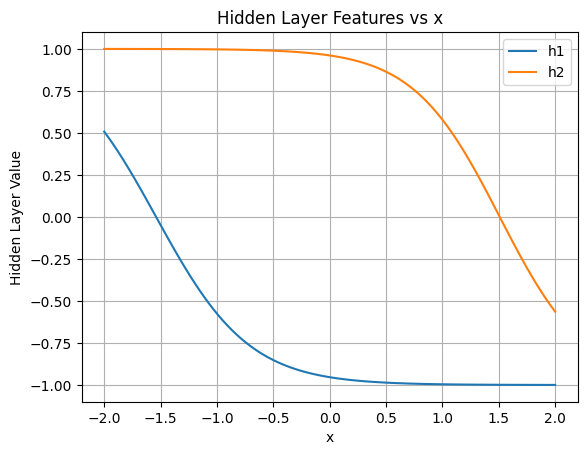

In [10]:
# get hidden layer outputs
with torch.no_grad():
    hidden = torch.tanh(model[0](x)) # take output of first layer and plug into hyperbolic tangent to get hidden layer features
    #hidden = torch.relu(model[0](x)) # change this for Question 6
h = hidden.numpy() # convert to numpy

for i in range(h.shape[1]):
    plt.plot(x.numpy(), h[:, i])

plt.title('Hidden Layer Features vs x')
plt.xlabel('x')
plt.ylabel('Hidden Layer Value')
plt.grid()
labels = [f'h{i}' for i in range(1, h.shape[1]+1)]
plt.legend(labels)
plt.show()


Here are the weights for $h_1$ and $h_2$ respectively as well as the bias term (intercept).

In [11]:
print(model[2].weight.detach())
print(model[2].bias.detach())

tensor([[ 2.6032, -2.5046]])
tensor([4.9542])


Below is the plot of the fit on the actual data, we see that it very accurately approximates the $y=x^2$ relationship despite the fact that $x^2$ is not an included feature.  So we are approximating $x^2$ by a weighted sum of simple non-linear functions of $x$.  

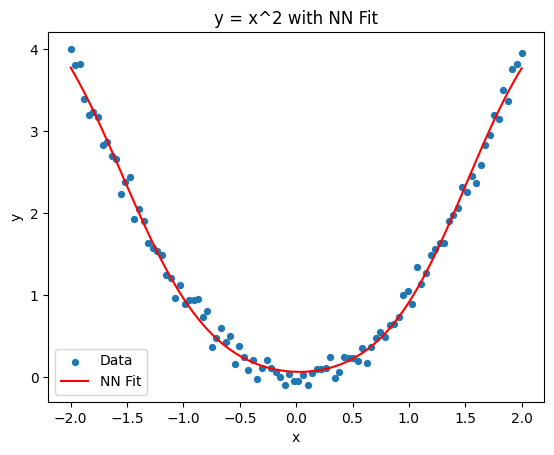

In [12]:
plt.scatter(x.numpy(), y.numpy(), label='Data', s=18)
plt.plot(x.numpy(), y_pred.numpy(), label='NN Fit', c = 'red')
plt.title('y = x^2 with NN Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

Conceptual Questions:

1.  Why do our input features not matter as much for neural networks (assuming we have a complex enough network)?

2.  What is the role of the hidden layer(s)?

3.  Why is stacking linear layers not effective/why do we need non-linear activation functions?

4.  Why can the final layer usually be something simple (linear, softmax, logistic)?

5.  What tends to happen if we add more neurons to a hidden layer/add more hidden layers?

6.  Change the model to use ReLU as the activation function (changes need to be made in the 2nd and 4th code blocks) and then run all again.  Why does ReLU with two nodes in the hidden layer fail to capture the $y=x^2$ shape while hyperbolic tangent works?

7.  What changes could we make to have ReLU work here? (Try it).

8.  What drawbacks do you think exist for neural networks relative to the simpler models covered previously?

9.  When would a simpler model (linear regression etc) be preferable?  Think of an example based on the nature of the question rather than the nature of the data.